In [15]:
import hashlib
import numpy as np 
import pandas as pd
import cv2
import matplotlib.pyplot as plt

In [16]:
# Generating a personalized random seed
username = "prit.kanadiya"
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)
print(seed)
np.random.seed(seed)

1379217023


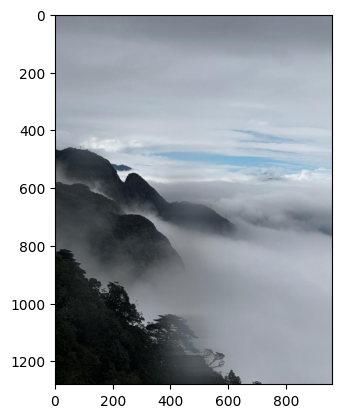

In [17]:
img_path = "../../data/cloudy_mountains.jpg"
# img_path = "../../data/rocking_horse.jpg"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

In [18]:
# We need to convert image to data
df = pd.DataFrame(columns=["X", "Y", "R", "G", "B"])

x, y = np.indices((img.shape[0], img.shape[1]))

df["X"] = np.ravel(x) / img.shape[0]
df["Y"] = np.ravel(y) / img.shape[1]
df["R"] = np.ravel(img[:,:,0]) / 255
df["G"] = np.ravel(img[:,:,1]) / 255
df["B"] = np.ravel(img[:,:,2]) / 255

print(df.info())
print(df.head())     

<class 'pandas.DataFrame'>
RangeIndex: 1228800 entries, 0 to 1228799
Data columns (total 5 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   X       1228800 non-null  float64
 1   Y       1228800 non-null  float64
 2   R       1228800 non-null  float64
 3   G       1228800 non-null  float64
 4   B       1228800 non-null  float64
dtypes: float64(5)
memory usage: 46.9 MB
None
     X         Y         R         G         B
0  0.0  0.000000  0.501961  0.517647  0.560784
1  0.0  0.001042  0.501961  0.517647  0.560784
2  0.0  0.002083  0.501961  0.517647  0.560784
3  0.0  0.003125  0.501961  0.517647  0.560784
4  0.0  0.004167  0.501961  0.517647  0.560784


In [25]:
class KMeans():
    def __init__(self, k: int, df: pd.DataFrame, distance_metric: str):
        self.k = k
        self.df = df
        self.distance_metric = distance_metric
        self.assignments = np.zeros(len(df))

        indices = np.random.choice(len(df), 3, replace=False)    # This will be the initial mean indices
        self.means = df.iloc[indices]
    
    def distance(self, x, y):
        """
        This computes distance between two df rows
        """
        x = x.to_numpy()
        y = y.to_numpy()

        x = np.expand_dims(x, axis=1)
        y = np.expand_dims(y, axis=0)

        print(x.shape)
        print(y.shape)

        dist = 0
        if (self.distance_metric == "manhattan"):
            dist = np.sum(np.abs(x - y), axis=2)
        elif (self.distance_metric == "euclidean"):
            dist = np.sqrt(np.sum(np.square(x - y), axis=2))
        
        return dist

    def e_step(self):
        """ 
        This will assign each datapoint to its nearest mean
        """
        dist = self.distance(self.df, self.means)
        print(dist.shape)
        

In [26]:
k = 3
distance_metric = "euclidean"

kmeans = KMeans(k, df, distance_metric)
kmeans.e_step()

(1228800, 1, 5)
(1, 3, 5)
(1228800, 3)
